# Time Series Forecasting dengan XGBoost - London Bike Sharing

In [1]:
# ============================================================
# 1. Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# XGBoost
import xgboost as xgb
from xgboost import XGBRegressor

# Preprocessing & Evaluation
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# SHAP
import shap

# Stats models (for EDA)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Data & Agregasi Harian

In [2]:
# Load data
df = pd.read_csv('london_merged.csv')
print(f"Shape awal: {df.shape}")
print(f"\nKolom: {df.columns.tolist()}")
df.head()

Shape awal: (17414, 10)

Kolom: ['timestamp', 'cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [3]:
# Konversi timestamp ke datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Set timestamp sebagai index
df = df.set_index('timestamp')

# ============================================================
# AGREGASI HARIAN: sum pada kolom cnt
# ============================================================
# Ambil hanya kolom cnt, lalu resample per hari dengan sum
df_daily = df[['cnt']].resample('D').sum()

print(f"Shape setelah agregasi harian: {df_daily.shape}")
print(f"Range tanggal: {df_daily.index.min()} s/d {df_daily.index.max()}")
df_daily.head(10)

Shape setelah agregasi harian: (731, 1)
Range tanggal: 2015-01-04 00:00:00 s/d 2017-01-03 00:00:00


,cnt
timestamp,
2015-01-04,9234
2015-01-05,20372
2015-01-06,20613
2015-01-07,21064
2015-01-08,15601
2015-01-09,22104
2015-01-10,14709
2015-01-11,14575
2015-01-12,17199


## 3. Exploratory Data Analysis (EDA)

In [4]:
# ============================================================
# 3.1 Statistik Deskriptif
# ============================================================
print("=" * 50)
print("STATISTIK DESKRIPTIF - Daily Bike Rentals (cnt)")
print("=" * 50)
df_daily['cnt'].describe().to_frame().T

STATISTIK DESKRIPTIF - Daily Bike Rentals (cnt)


,count,mean,std,min,25%,50%,75%,max
cnt,731.0,27231.151847,8660.727499,0.0,21912.0,27001.0,33427.5,72504.0


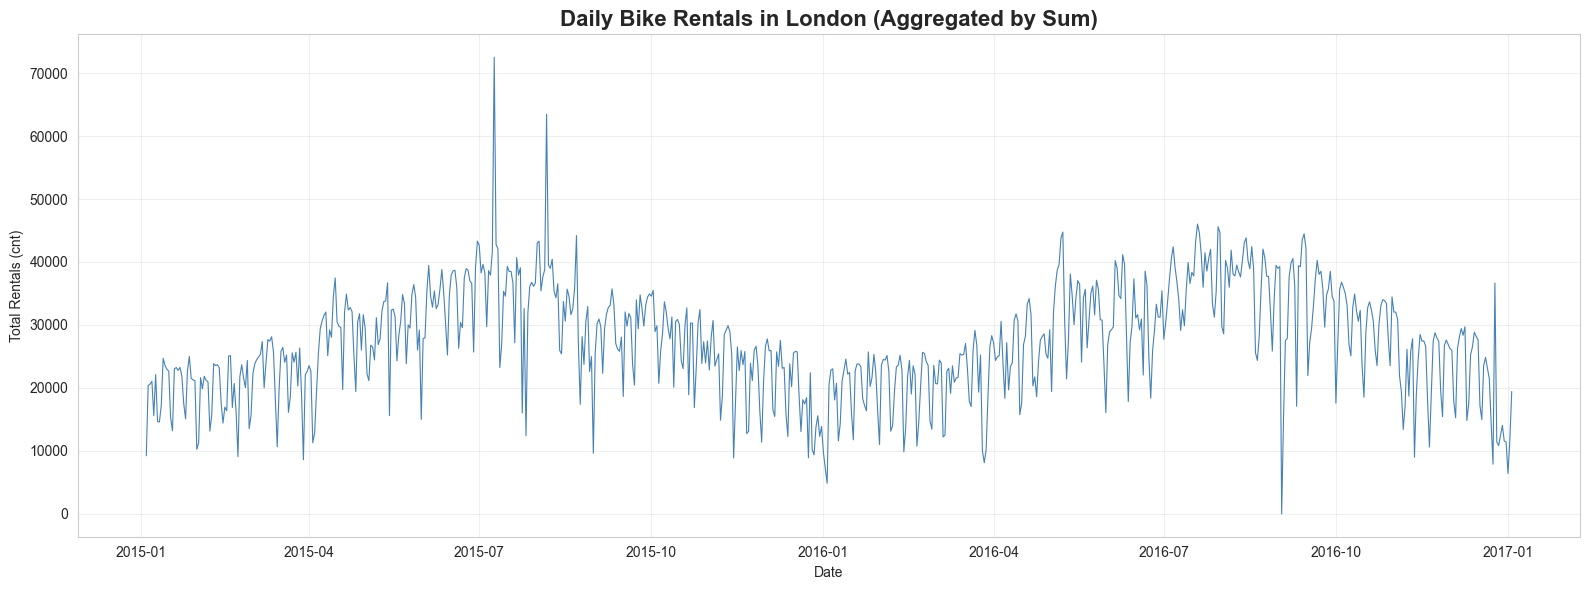

In [5]:
# ============================================================
# 3.2 Plot Time Series - Daily Bike Rentals
# ============================================================
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_daily.index, df_daily['cnt'], color='steelblue', linewidth=0.8)
ax.set_title('Daily Bike Rentals in London (Aggregated by Sum)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Rentals (cnt)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

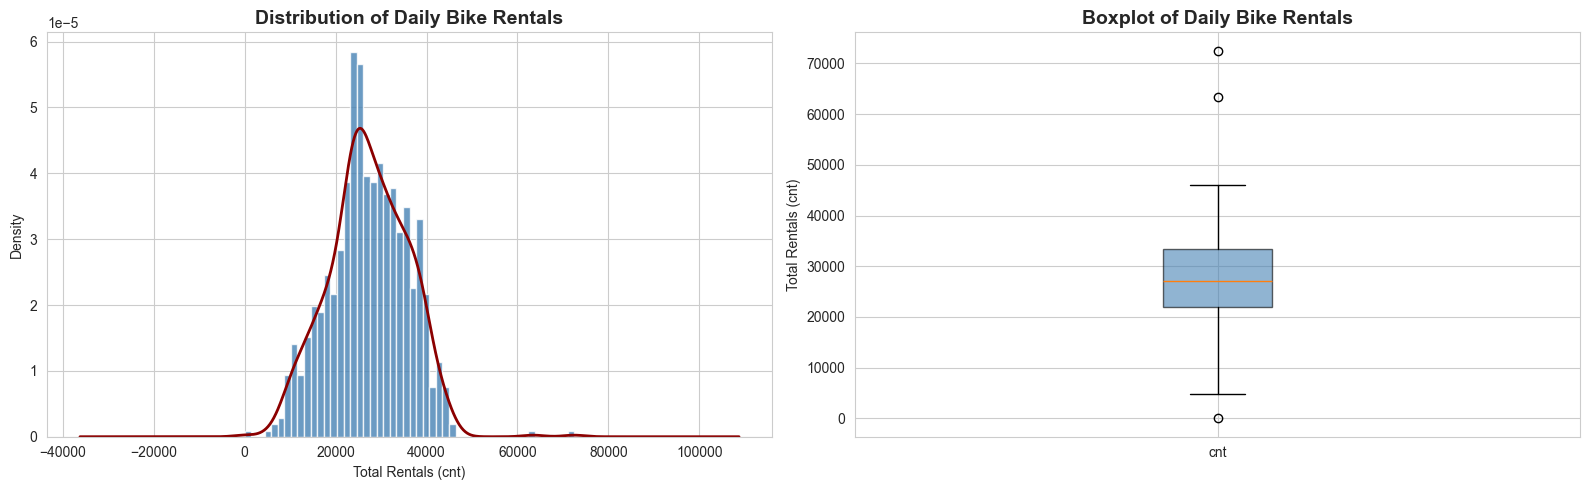


Missing values:
cnt    0
dtype: int64


In [6]:
# ============================================================
# 3.3 Distribusi & Boxplot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram + KDE
axes[0].hist(df_daily['cnt'], bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
df_daily['cnt'].plot.kde(ax=axes[0], color='darkred', linewidth=2)
axes[0].set_title('Distribution of Daily Bike Rentals', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Rentals (cnt)')
axes[0].set_ylabel('Density')

# Boxplot
axes[1].boxplot(df_daily['cnt'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot of Daily Bike Rentals', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Rentals (cnt)')
axes[1].set_xticklabels(['cnt'])

plt.tight_layout()
plt.show()

# Check missing values
print(f"\nMissing values:\n{df_daily.isnull().sum()}")

ValueError: np.str_('steelbl') is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

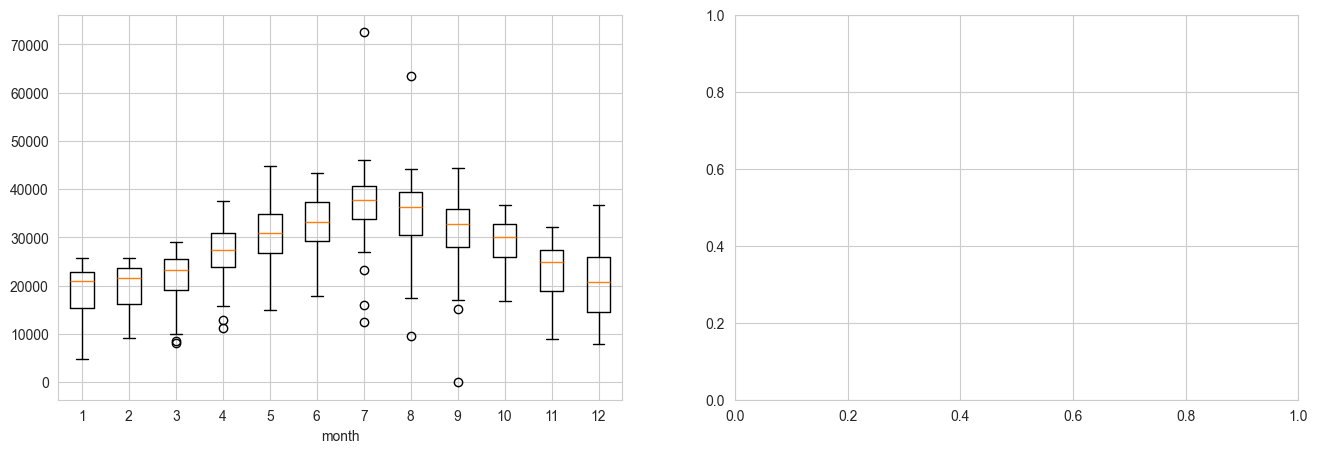

In [7]:
# ============================================================
# 3.4 Boxplot per Bulan & per Hari dalam Seminggu
# ============================================================
df_eda = df_daily.copy()
df_eda['month'] = df_eda.index.month
df_eda['dayofweek'] = df_eda.index.dayofweek  # Monday=0, Sunday=6
df_eda['year'] = df_eda.index.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot per bulan
df_eda.boxplot(column='cnt', by='month', ax=axes[0], color='steelblue')
axes[0].set_title('Daily Rentals by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Rentals (cnt)')

# Boxplot per hari
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_eda.boxplot(column='cnt', by='dayofweek', ax=axes[1], color='darkorange')
axes[1].set_title('Daily Rentals by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Rentals (cnt)')
axes[1].set_xticklabels(day_labels)

plt.suptitle('')
plt.tight_layout()
plt.show()

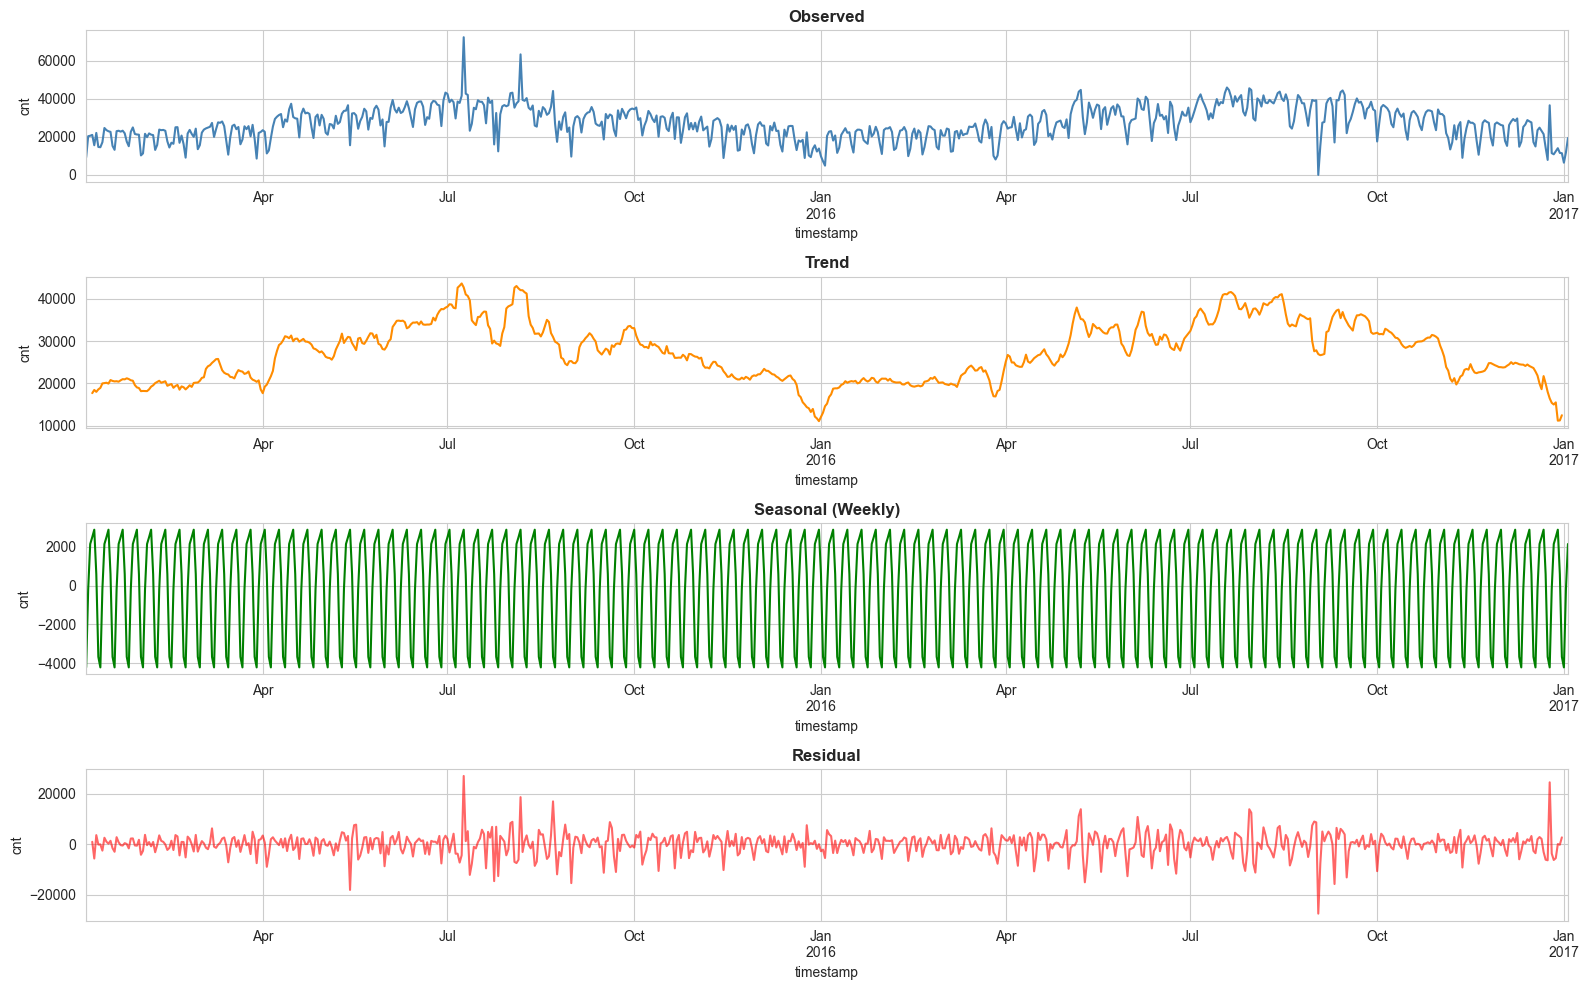

In [8]:
# ============================================================
# 3.5 Seasonal Decomposition
# ============================================================
decomposition = seasonal_decompose(df_daily['cnt'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed', fontweight='bold')
axes[0].set_ylabel('cnt')

decomposition.trend.plot(ax=axes[1], color='darkorange')
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('cnt')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonal (Weekly)', fontweight='bold')
axes[2].set_ylabel('cnt')

decomposition.resid.plot(ax=axes[3], color='red', alpha=0.6)
axes[3].set_title('Residual', fontweight='bold')
axes[3].set_ylabel('cnt')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

**Fitur yang dibuat:**
- `lag_1` : nilai cnt 1 hari sebelumnya
- `lag_2` : nilai cnt 2 hari sebelumnya
- `month` : bulan (1-12)
- `is_weekend` : apakah akhir pekan (1) atau bukan (0)

> **Catatan:** `lag_2` disiapkan sebagai kandidat di hyperparameter tuning. Nanti model akan memilih apakah hanya pakai `lag_1` atau `lag_1 + lag_2`.

In [9]:
# ============================================================
# 4.1 Membuat DataFrame dengan Fitur
# ============================================================
df_model = df_daily.copy()

# --- Lag Features: nilai cnt hari sebelumnya ---
df_model['lag_1'] = df_model['cnt'].shift(1)
df_model['lag_2'] = df_model['cnt'].shift(2)

# --- Month ---
df_model['month'] = df_model.index.month

# --- Is Weekend ---
# dayofweek: Monday=0, Sunday=6  -> weekend = Sabtu(5) & Minggu(6)
df_model['is_weekend'] = df_model.index.dayofweek.isin([5, 6]).astype(int)

# Hapus baris dengan NaN (akibat shift)
df_model = df_model.dropna()

print(f"Shape setelah feature engineering: {df_model.shape}")
print(f"\nKolom: {df_model.columns.tolist()}")
df_model.head(10)

Shape setelah feature engineering: (729, 5)

Kolom: ['cnt', 'lag_1', 'lag_2', 'month', 'is_weekend']


,cnt,lag_1,lag_2,month,is_weekend
timestamp,,,,,
2015-01-06,20613,20372.0,9234.0,1,0
2015-01-07,21064,20613.0,20372.0,1,0
2015-01-08,15601,21064.0,20613.0,1,0
2015-01-09,22104,15601.0,21064.0,1,0
2015-01-10,14709,22104.0,15601.0,1,1
2015-01-11,14575,14709.0,22104.0,1,1
2015-01-12,17199,14575.0,14709.0,1,0
2015-01-13,24697,17199.0,14575.0,1,0
2015-01-14,23565,24697.0,17199.0,1,0


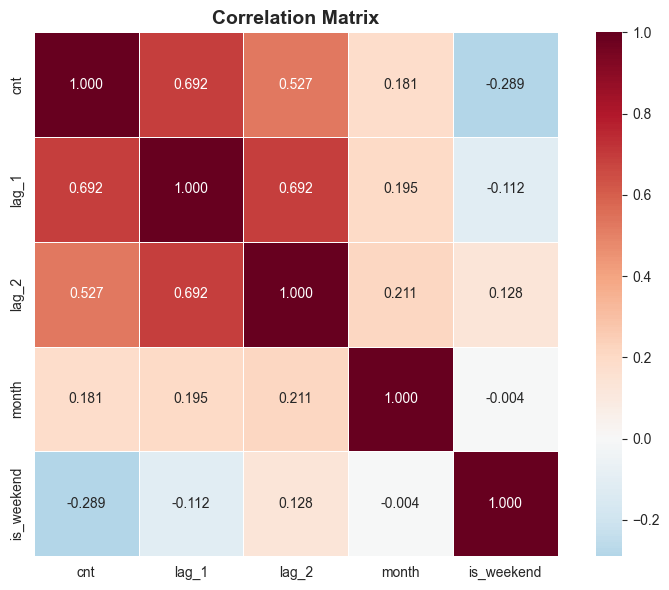

In [10]:
# ============================================================
# 4.2 Korelasi Antar Fitur
# ============================================================
plt.figure(figsize=(8, 6))
corr = df_model.corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Modelling dengan XGBoost

> **Strategy:** Time series split 60/20/20 → Train / Validation / Test. Hyperparameter tuning dilakukan di **validation set**, test set **tidak disentuh sama sekali** sampai evaluasi final.

In [11]:
# ============================================================
# 5.1 Train-Val-Test Split (Time-based, chronological order!)
# ============================================================
# Semua fitur yang tersedia (lag_2 sebagai kandidat tuning)
ALL_FEATURES = ['lag_1', 'lag_2', 'month', 'is_weekend']
TARGET = 'cnt'

X = df_model[ALL_FEATURES]
y = df_model[TARGET]

# Split: 60% train, 20% validation, 20% test (chronological)
n = len(df_model)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print(f"Total data: {n} hari")
print(f"Train: {X_train.shape[0]} samples ({X_train.index[0].date()} s/d {X_train.index[-1].date()})")
print(f"Val  : {X_val.shape[0]} samples ({X_val.index[0].date()} s/d {X_val.index[-1].date()})")
print(f"Test : {X_test.shape[0]} samples ({X_test.index[0].date()} s/d {X_test.index[-1].date()})")
print(f"\nAvailable features: {ALL_FEATURES}")
print(f"🚨 TEST SET TIDAK BOLEH DISENTUH sampai evaluasi final!")

Total data: 729 hari
Train: 437 samples (2015-01-06 s/d 2016-03-17)
Val  : 146 samples (2016-03-18 s/d 2016-08-10)
Test : 146 samples (2016-08-11 s/d 2017-01-03)

Available features: ['lag_1', 'lag_2', 'month', 'is_weekend']
🚨 TEST SET TIDAK BOLEH DISENTUH sampai evaluasi final!


In [12]:
# ============================================================
# 5.2 Hyperparameter Tuning (pada VALIDATION set!)
# ============================================================

# --- Kandidat parameter ---
lag_candidates = [['lag_1'], ['lag_1', 'lag_2']]  # 2 kandidat
max_depth_candidates = [3, 5]                       # 2 kandidat
learning_rate_candidates = [0.03, 0.05, 0.1]        # 3 kandidat
n_estimators_candidates = [100, 300]                # 2 kandidat

# --- Fungsi evaluasi tuning ---
def smape(y_true, y_pred):
    """Symmetric MAPE - robust terhadap nilai actual ~ 0"""
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

# --- Grid search manual ---
results = []

print("🔍 Hyperparameter Tuning (24 kombinasi)...")
print("=" * 70)

# Iterasi semua kombinasi (2 × 2 × 3 × 2 = 24)
total = len(lag_candidates) * len(max_depth_candidates) * len(learning_rate_candidates) * len(n_estimators_candidates)
combo_num = 0

for lag_feats in lag_candidates:
    for max_d in max_depth_candidates:
        for lr in learning_rate_candidates:
            for n_est in n_estimators_candidates:
                combo_num += 1
                
                # Pilih fitur sesuai kandidat lag
                X_train_sub = X_train[lag_feats + ['month', 'is_weekend']]
                X_val_sub   = X_val[lag_feats + ['month', 'is_weekend']]
                
                # Train model
                model = XGBRegressor(
                    n_estimators=n_est,
                    max_depth=max_d,
                    learning_rate=lr,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    objective='reg:squarederror',
                    verbosity=0
                )
                model.fit(X_train_sub, y_train)
                
                # Predict on VALIDATION
                y_pred_val = model.predict(X_val_sub)
                smape_val = smape(y_val, y_pred_val)
                
                results.append({
                    'lag_features': '+'.join(lag_feats),
                    'max_depth': max_d,
                    'learning_rate': lr,
                    'n_estimators': n_est,
                    'sMAPE_val': round(smape_val, 2)
                })
                
                print(f"  [{combo_num:2d}/{total}] lag=({' + '.join(lag_feats):22s}) | "
                      f"depth={max_d} | lr={lr:.2f} | n_est={n_est:3d} → sMAPE_val = {smape_val:.2f}%")

# --- Hasil tuning ---
df_results = pd.DataFrame(results).sort_values('sMAPE_val')
print(f"\n{'='*70}")
print("📊 BEST 5 CONFIGURATIONS (by sMAPE on Validation):")
print(f"{'='*70}")
display(df_results.head(5))

# --- Ambil yang terbaik ---
best = df_results.iloc[0]
best_lag_feats = best['lag_features'].split('+')
BEST_FEATURES = best_lag_feats + ['month', 'is_weekend']

print(f"\n✅ BEST CONFIGURATION:")
print(f"   Features     : {BEST_FEATURES}")
print(f"   max_depth    : {best['max_depth']}")
print(f"   learning_rate: {best['learning_rate']}")
print(f"   n_estimators : {best['n_estimators']}")
print(f"   sMAPE (val)  : {best['sMAPE_val']:.2f}%")

🔍 Hyperparameter Tuning (24 kombinasi)...
  [ 1/24] lag=(lag_1                 ) | depth=3 | lr=0.03 | n_est=100 → sMAPE_val = 14.66%
  [ 2/24] lag=(lag_1                 ) | depth=3 | lr=0.03 | n_est=300 → sMAPE_val = 15.32%
  [ 3/24] lag=(lag_1                 ) | depth=3 | lr=0.05 | n_est=100 → sMAPE_val = 14.96%
  [ 4/24] lag=(lag_1                 ) | depth=3 | lr=0.05 | n_est=300 → sMAPE_val = 15.78%
  [ 5/24] lag=(lag_1                 ) | depth=3 | lr=0.10 | n_est=100 → sMAPE_val = 15.26%
  [ 6/24] lag=(lag_1                 ) | depth=3 | lr=0.10 | n_est=300 → sMAPE_val = 16.83%
  [ 7/24] lag=(lag_1                 ) | depth=5 | lr=0.03 | n_est=100 → sMAPE_val = 15.06%
  [ 8/24] lag=(lag_1                 ) | depth=5 | lr=0.03 | n_est=300 → sMAPE_val = 16.30%
  [ 9/24] lag=(lag_1                 ) | depth=5 | lr=0.05 | n_est=100 → sMAPE_val = 15.73%
  [10/24] lag=(lag_1                 ) | depth=5 | lr=0.05 | n_est=300 → sMAPE_val = 17.47%
  [11/24] lag=(lag_1                 )

,lag_features,max_depth,learning_rate,n_estimators,sMAPE_val
0,lag_1,3,0.03,100,14.66
2,lag_1,3,0.05,100,14.96
6,lag_1,5,0.03,100,15.06
4,lag_1,3,0.10,100,15.26
1,lag_1,3,0.03,300,15.32



✅ BEST CONFIGURATION:
   Features     : ['lag_1', 'month', 'is_weekend']
   max_depth    : 3
   learning_rate: 0.03
   n_estimators : 100
   sMAPE (val)  : 14.66%


## 6. Evaluasi Model (Final — Best Model)

> Model terbaik dari tuning dilatih ulang pada **train set**, lalu dievaluasi di train, validation, dan test set.

In [13]:
# ============================================================
# 6.1 Final Model: Train dengan Best Params, Evaluasi di Semua Set
# ============================================================

# --- Train final model dengan best configuration ---
X_train_best = X_train[BEST_FEATURES]
X_val_best   = X_val[BEST_FEATURES]
X_test_best  = X_test[BEST_FEATURES]

final_model = XGBRegressor(
    n_estimators=int(best['n_estimators']),
    max_depth=int(best['max_depth']),
    learning_rate=best['learning_rate'],
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    verbosity=0
)

final_model.fit(X_train_best, y_train)
print("✅ Final model trained on TRAIN set only!")

# --- Prediksi ---
y_pred_train = final_model.predict(X_train_best)
y_pred_val   = final_model.predict(X_val_best)
y_pred_test  = final_model.predict(X_test_best)

# --- Fungsi evaluasi ---
def smape(y_true, y_pred):
    """Symmetric MAPE - tidak meledak saat actual ~ 0"""
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

def evaluate(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sMAPE_val = smape(y_true, y_pred)

    return pd.DataFrame({
        'Dataset': [dataset_name],
        'MAE': [f'{mae:.2f}'],
        'RMSE': [f'{rmse:.2f}'],
        'R²': [f'{r2:.4f}'],
        'sMAPE (%)': [f'{sMAPE_val:.2f}']
    })

# --- Diagnosis: cek hari dengan cnt sangat kecil ---
cnt_all = pd.concat([y_train, y_val, y_test])
low_cnt_mask = cnt_all < 100
if low_cnt_mask.sum() > 0:
    print("⚠️  PERINGATAN: Data memiliki hari dengan cnt < 100!")
    print(f"   Jumlah hari: {low_cnt_mask.sum()}")
    print(f"   Nilai minimum: {cnt_all.min():.0f}")
    print(f"   → Gunakan sMAPE (Symmetric MAPE) sebagai metrik yang robust.\n")

# --- Evaluasi semua set ---
df_eval_train = evaluate(y_train, y_pred_train, 'Train')
df_eval_val   = evaluate(y_val,   y_pred_val,   'Validation')
df_eval_test  = evaluate(y_test,  y_pred_test,  'Test 🚨 (untouched!)')

print("=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)
df_all = pd.concat([df_eval_train, df_eval_val, df_eval_test], ignore_index=True)
display(df_all)

print(f"\n📌 Best features used: {BEST_FEATURES}")
print(f"📌 Tuning metric: sMAPE on Validation = {best['sMAPE_val']:.2f}%")

✅ Final model trained on TRAIN set only!
⚠️  PERINGATAN: Data memiliki hari dengan cnt < 100!
   Jumlah hari: 1
   Nilai minimum: 0
   → Gunakan sMAPE (Symmetric MAPE) sebagai metrik yang robust.

FINAL MODEL EVALUATION


,Dataset,MAE,RMSE,R²,sMAPE (%)
0,Train,3151.77,4525.16,0.7025,13.25
1,Validation,4235.61,5355.38,0.5247,14.66
2,Test 🚨 (untouched!),4263.72,6287.59,0.5333,17.80



📌 Best features used: ['lag_1', 'month', 'is_weekend']
📌 Tuning metric: sMAPE on Validation = 14.66%


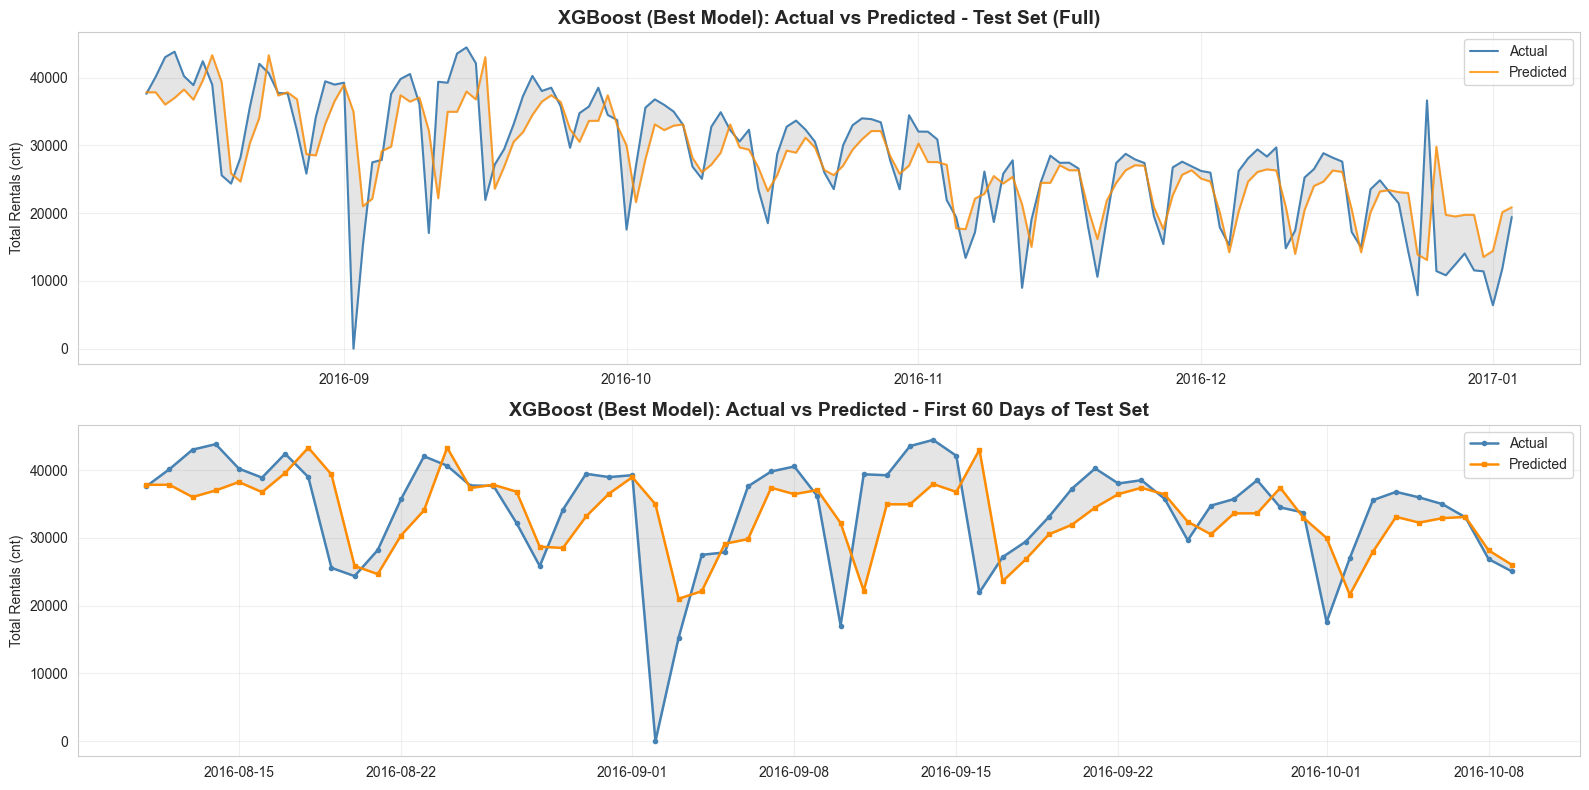

In [14]:
# ============================================================
# 6.2 Plot Actual vs Predicted (Test Set)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Full actual vs predicted
axes[0].plot(y_test.index, y_test.values, label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(y_test.index, y_pred_test, label='Predicted', color='darkorange', linewidth=1.5, alpha=0.8)
axes[0].fill_between(y_test.index, y_test.values, y_pred_test, alpha=0.2, color='gray')
axes[0].set_title('XGBoost (Best Model): Actual vs Predicted - Test Set (Full)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Rentals (cnt)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom 60 hari pertama test set
zoom = min(60, len(y_test))
axes[1].plot(y_test.index[:zoom], y_test.values[:zoom], label='Actual', color='steelblue',
             linewidth=1.8, marker='o', markersize=3)
axes[1].plot(y_test.index[:zoom], y_pred_test[:zoom], label='Predicted', color='darkorange',
             linewidth=1.8, marker='s', markersize=3)
axes[1].fill_between(y_test.index[:zoom], y_test.values[:zoom], y_pred_test[:zoom],
                     alpha=0.2, color='gray')
axes[1].set_title(f'XGBoost (Best Model): Actual vs Predicted - First {zoom} Days of Test Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Rentals (cnt)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 6.3 Residual Analysis (Test Set)
# ============================================================
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Residual over time
axes[0].scatter(y_test.index, residuals, alpha=0.5, color='steelblue', s=10)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals Over Time (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

print(f"Mean Residual : {np.mean(residuals):.2f}")
print(f"Std Residual  : {np.std(residuals):.2f}")

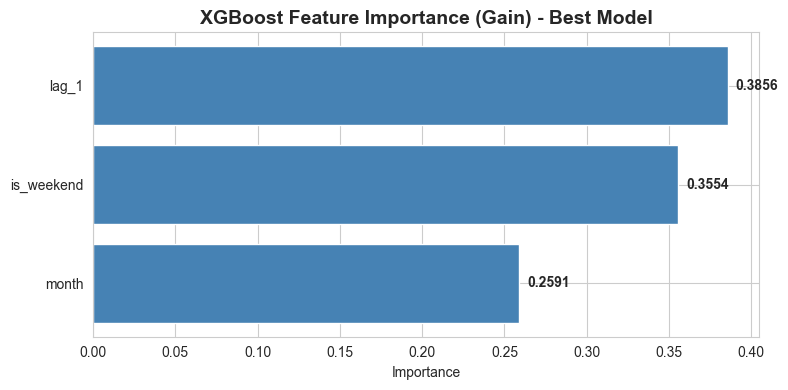

In [15]:
# ============================================================
# 6.4 Feature Importance (XGBoost built-in)
# ============================================================
feat_imp = pd.DataFrame({
    'Feature': BEST_FEATURES,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='white')
ax.set_title('XGBoost Feature Importance (Gain) - Best Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')

for i, (feat, imp) in enumerate(zip(feat_imp['Feature'], feat_imp['Importance'])):
    ax.text(imp + 0.005, i, f'{imp:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. SHAP Value Analysis

SHAP (SHapley Additive exPlanations) digunakan untuk menginterpretasi kontribusi setiap fitur terhadap prediksi model.

In [16]:
# ============================================================
# 7.1 SHAP Explainer
# ============================================================
# Gunakan TreeExplainer untuk model tree-based
explainer = shap.TreeExplainer(final_model)

# Hitung SHAP values untuk test set
shap_values = explainer.shap_values(X_test_best)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base value): {explainer.expected_value:.2f}")

SHAP values shape: (146, 3)
Expected value (base value): 25759.95


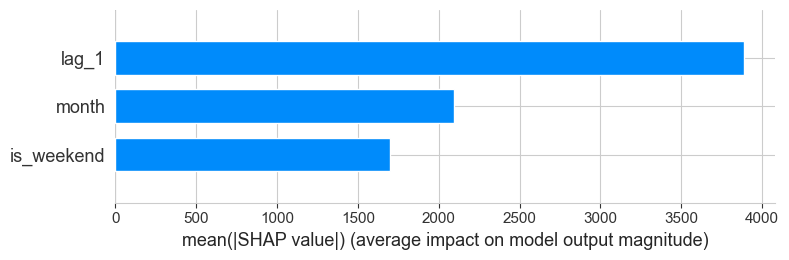

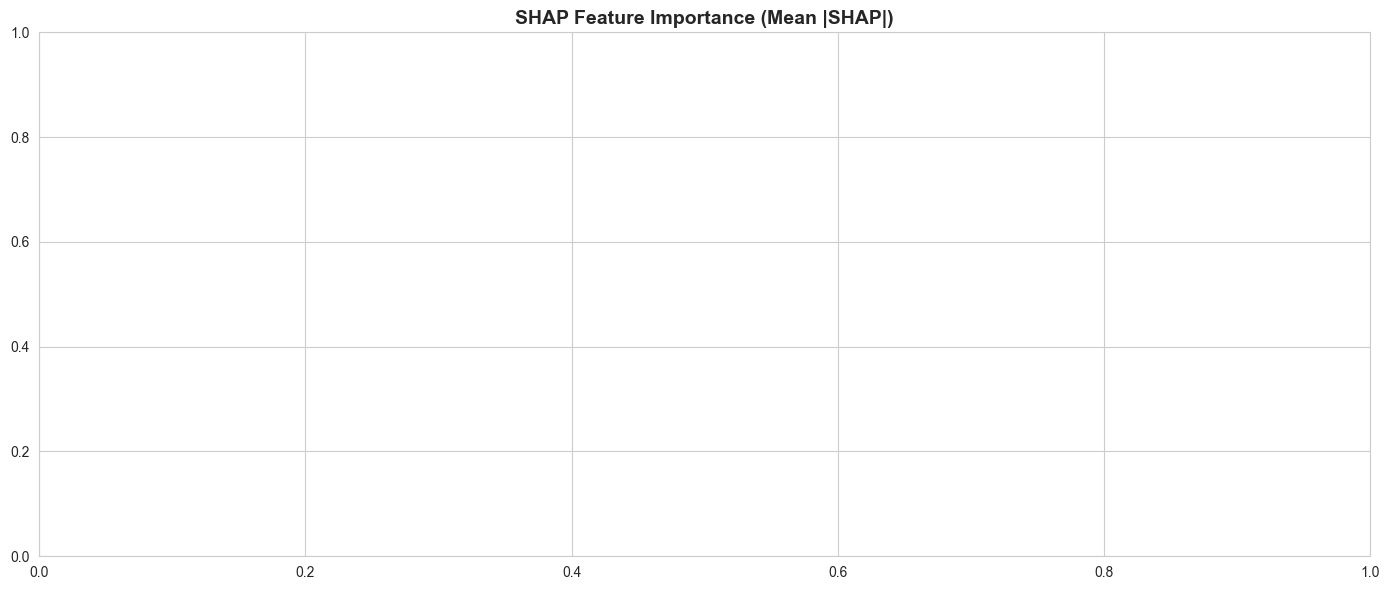

In [17]:
# ============================================================
# 7.2 SHAP Summary Plot (Bar)
# ============================================================
shap.summary_plot(shap_values, X_test_best, plot_type="bar", feature_names=BEST_FEATURES, show=True)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

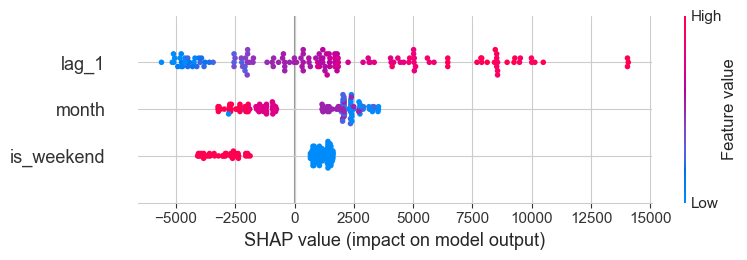

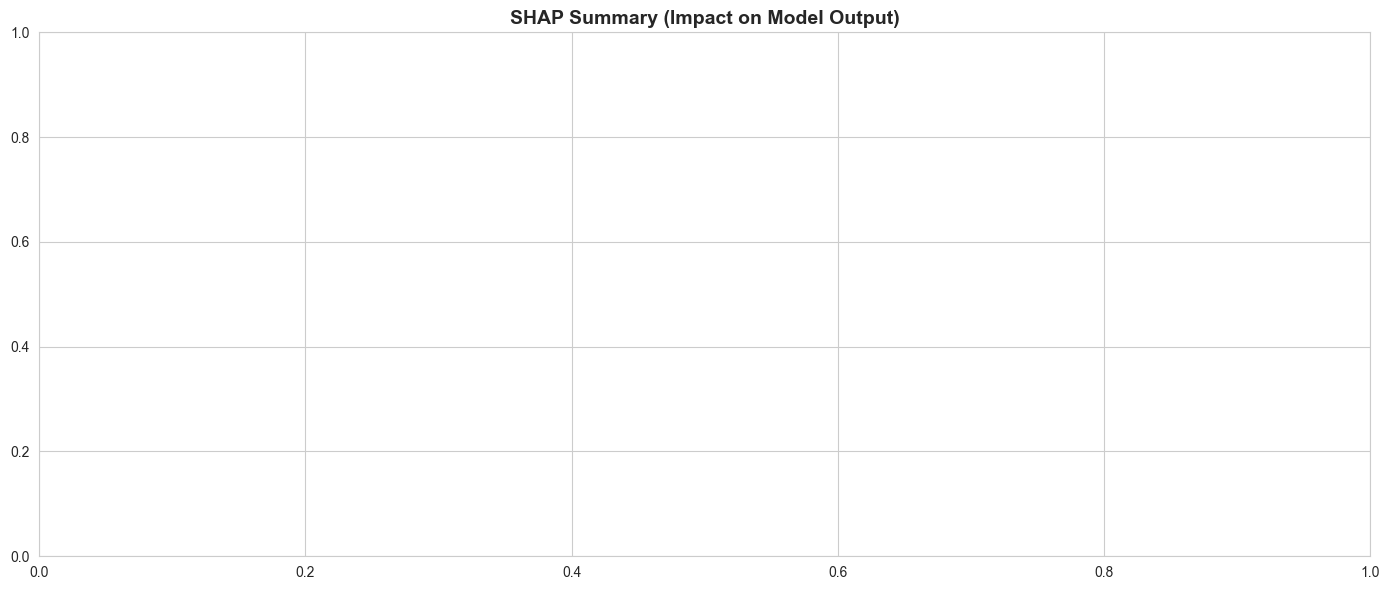

In [18]:
# ============================================================
# 7.3 SHAP Summary Plot (Dot/ Beeswarm)
# ============================================================
shap.summary_plot(shap_values, X_test_best, feature_names=BEST_FEATURES, show=True)
plt.title('SHAP Summary (Impact on Model Output)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

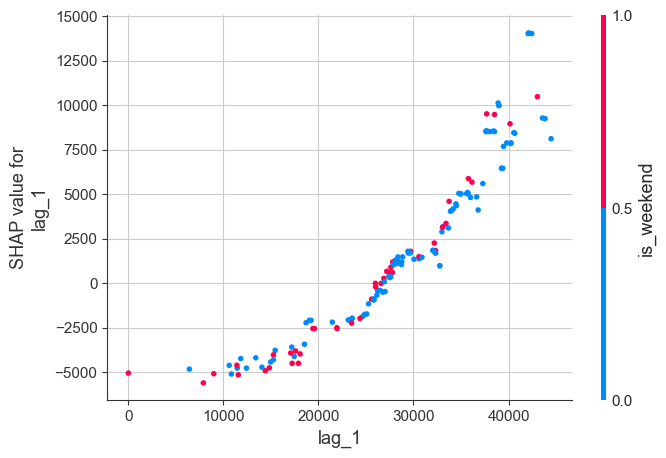

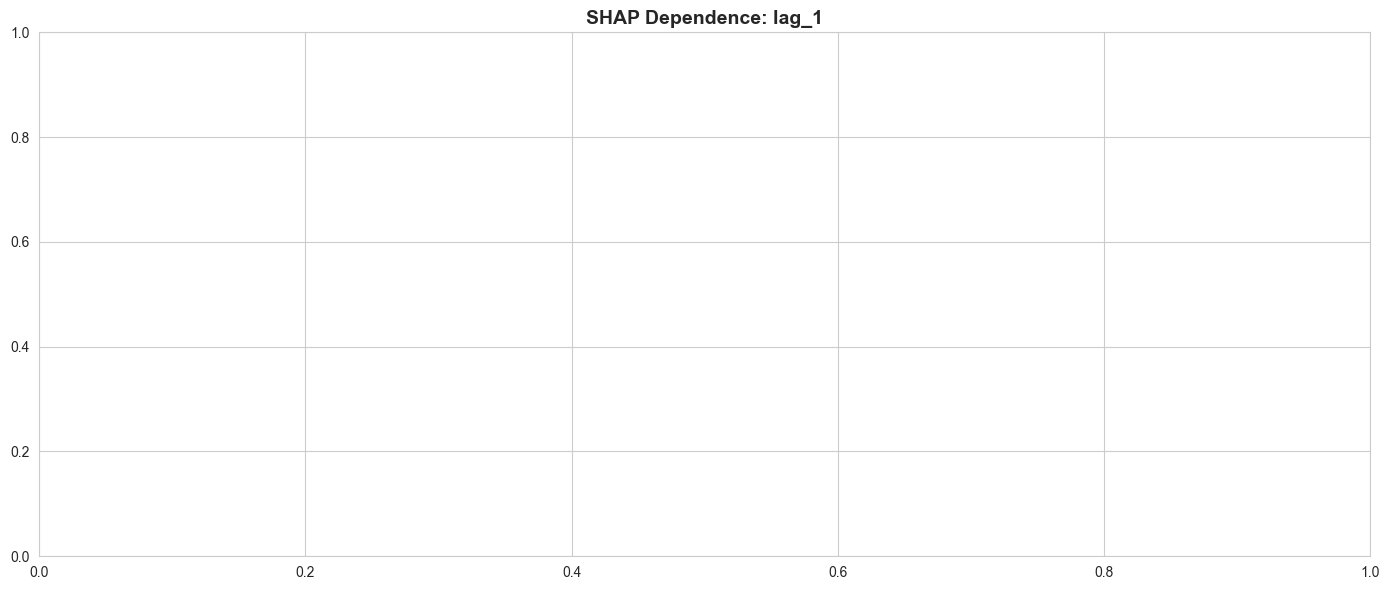

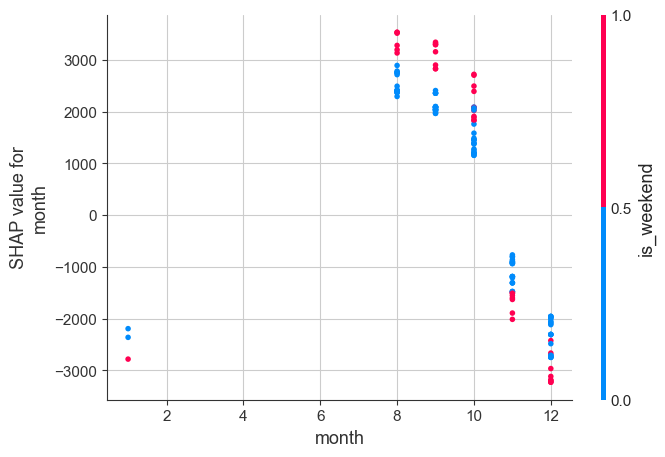

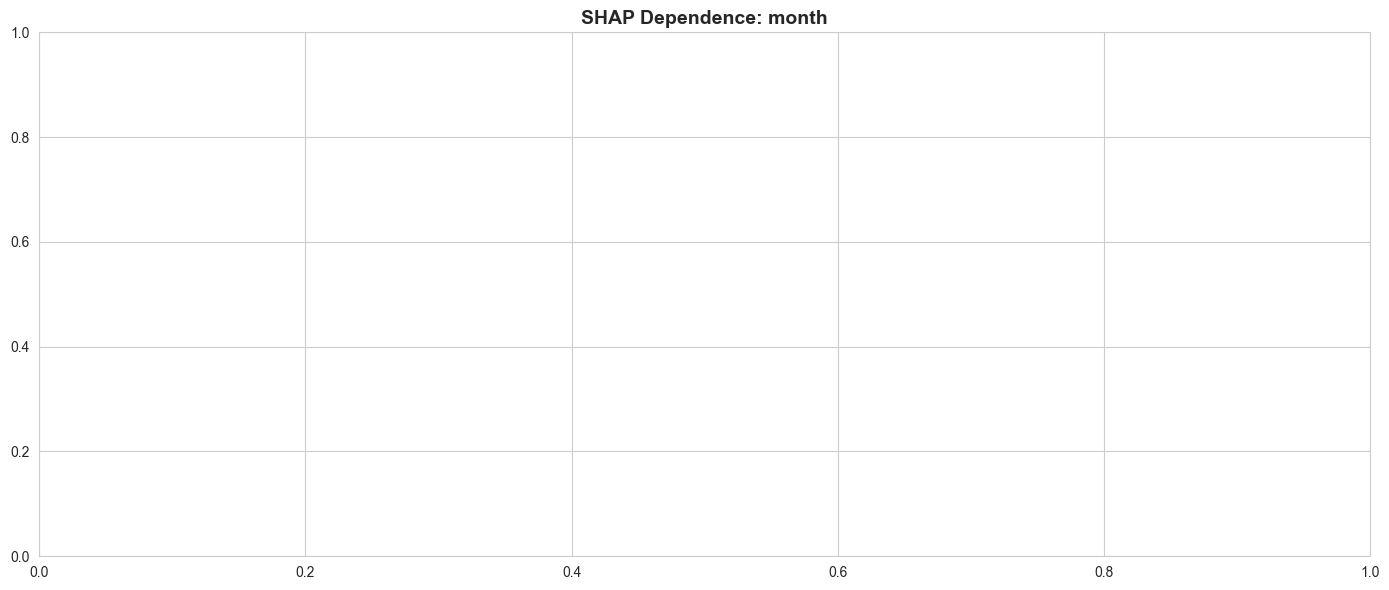

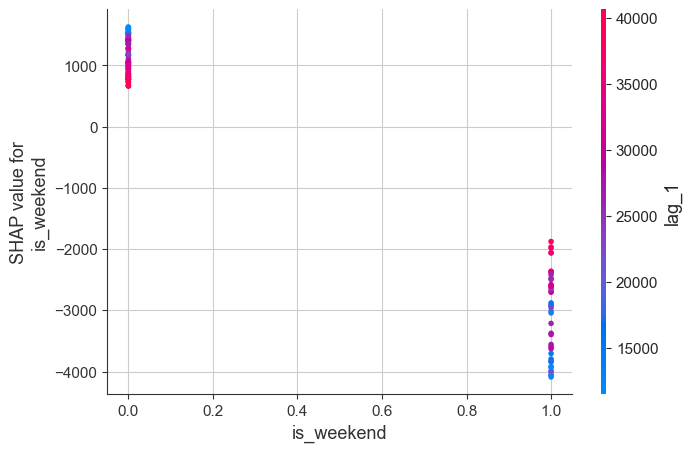

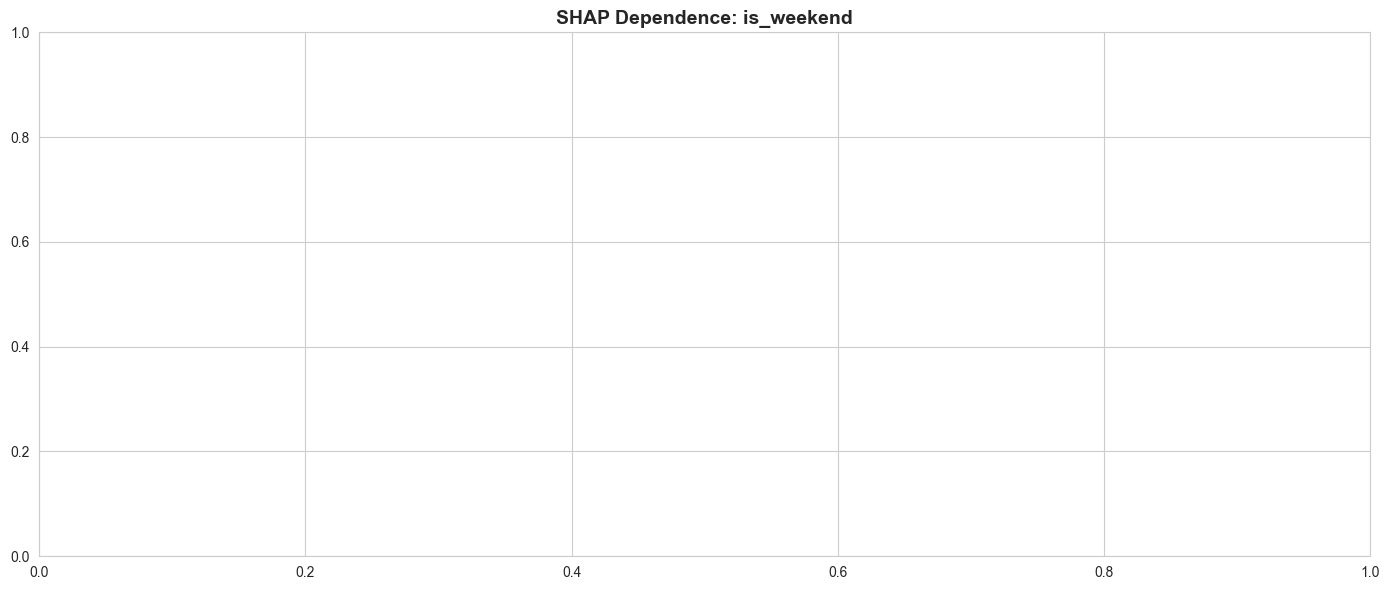

In [19]:
# ============================================================
# 7.4 SHAP Dependence Plot untuk Fitur Terpenting
# ============================================================
# Dependence plot untuk setiap fitur
for feature in BEST_FEATURES:
    shap.dependence_plot(feature, shap_values, X_test_best, feature_names=BEST_FEATURES, show=True)
    plt.title(f'SHAP Dependence: {feature}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

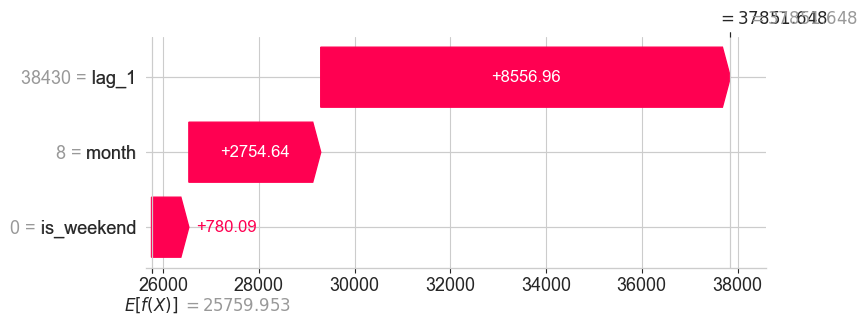

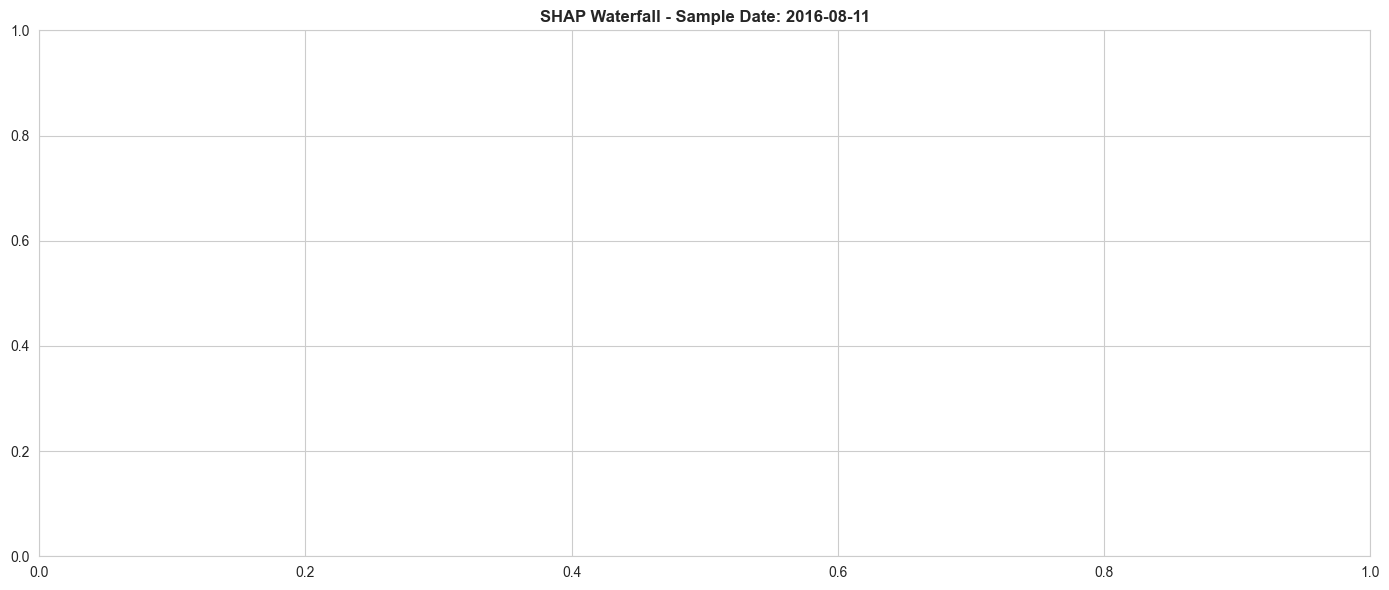

Actual value : 37626
Predicted    : 37852
Base value   : 25760


In [20]:
# ============================================================
# 7.5 SHAP Waterfall Plot (satu prediksi contoh)
# ============================================================
# Pilih satu sampel dari test set (misal index ke-0)
sample_idx = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_best.iloc[sample_idx].values,
        feature_names=BEST_FEATURES
    ),
    show=True
)
plt.title(f'SHAP Waterfall - Sample Date: {X_test_best.index[sample_idx].date()}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Actual value : {y_test.iloc[sample_idx]:.0f}")
print(f"Predicted    : {y_pred_test[sample_idx]:.0f}")
print(f"Base value   : {explainer.expected_value:.0f}")